In [ ]:
import json
import numpy as np
import networkx as nx
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from ND2.utils.plot import get_fig

/tmp/ipykernel_3839095/1654702940.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(result, x='class', y='success', ax=ax, palette=['#0984e3', '#d63031'], capsize=0.1)
/tmp/ipykernel_3839095/1654702940.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x='class', y='time', ax=ax, palette=['#636e72', '#0984e3'], capsize=0.1)
/tmp/ipykernel_3839095/1654702940.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x='class', y='time', ax=ax, palette=['#636e72', '#d63031'], capsize=0.1)


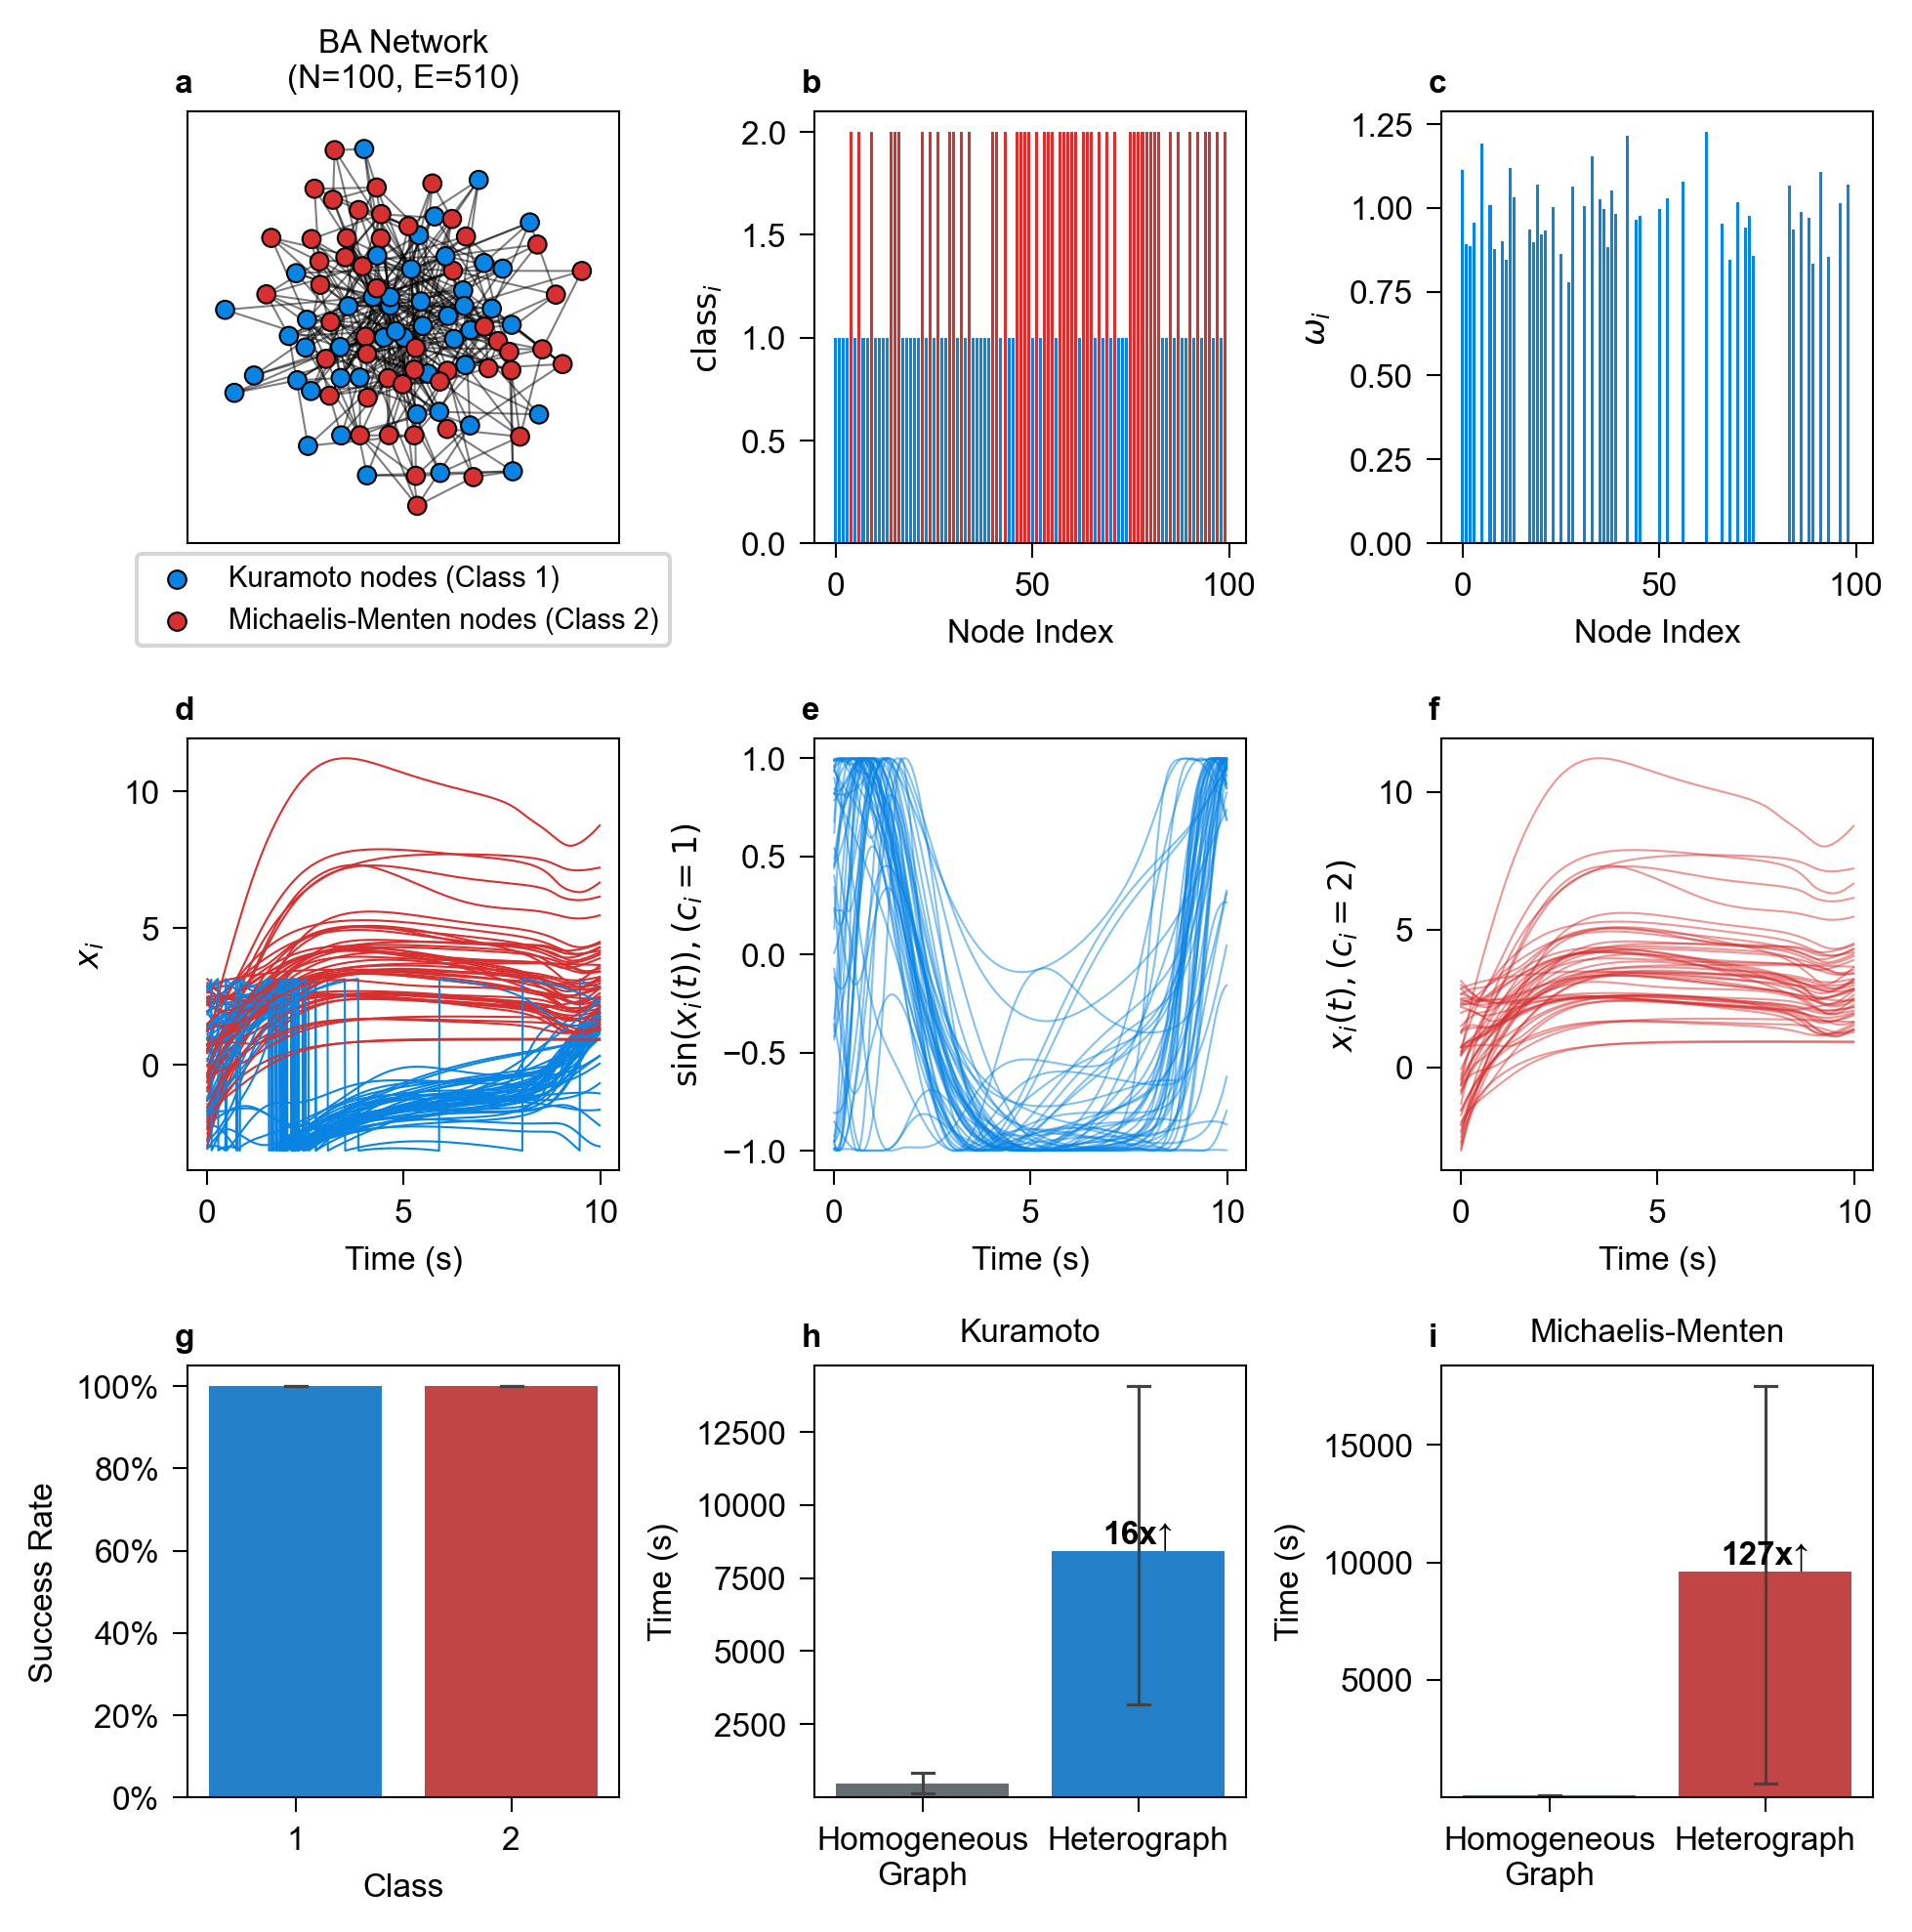

In [ ]:
fi, fig, axes = get_fig(3, 3, FW=18, LM=6, RM=6, TM=6, BM=6, HS=6, VS=6, fontsize=8)

data = json.load(open('./data/hetero/KUR_MM.json', 'r'))
for k, v in data.items():
    data[k] = np.array(v)
graph = nx.from_numpy_array(np.array(data['A']).astype(int))

ax = axes[0]
pos = nx.spring_layout(graph)
node_color = ['#0984e3' if k > 0 else '#d63031' for k in data['K']]
nx.draw_networkx_edges(graph, pos, ax=ax, width=0.5, alpha=0.5)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=20, node_color=node_color, edgecolors='k', linewidths=0.5)
ax.set_title(f'BA Network\n(N={len(data["K"])}, E={len(data["G"])})')
ax.legend(
    [
        plt.scatter([], [], color='#0984e3', label='Positive', edgecolors='k', linewidths=0.5, s=20),
        plt.scatter([], [], color='#d63031', label='Negative', edgecolors='k', linewidths=0.5, s=20),
    ],
    [ 'Kuramoto nodes (Class 1)', 'Michaelis-Menten nodes (Class 2)' ],
    loc='lower center', fontsize=7,
    bbox_to_anchor=(0.5, -0.27),
)

ax = axes[1]
colors = ['#0984e3' if k > 0 else '#d63031' for k in data['K']]
ax.bar(np.arange(len(data['K'])), 1.5-data['K']/2, color=colors, width=0.75)
ax.set_xlabel('Node Index')
ax.set_ylabel(r'$\mathrm{class}_i$')

ax = axes[2]
ax.bar(np.arange(len(data['omega'])), np.where(data['K'] > 0, data['omega'], 0), color=colors, width=0.75)
ax.set_xlabel('Node Index')
ax.set_ylabel(r'$\omega_i$')

ax = axes[3]
time = np.arange(1000) * 0.01
for i in range(100):
    if data['K'][i] > 0:
        x = np.array(data['x'])[:, i]
    else:
        x = np.array(data['x'])[:, i]
    ax.plot(time, x, label=f'Node {i+1}', color=node_color[i])
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$x_i$')

ax = axes[4]
ax.plot(time, np.sin(data['x'][:, data['K'] > 0]), color='#0984e3', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\sin(x_i(t)),  (c_i = 1)$')

ax = axes[5]
ax.plot(time, data['x'][:, data['K'] < 0], color='#d63031', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$x_i(t),  (c_i = 2)$')

ax = axes[6]
result = pd.read_json('./result/hetero.json')
result['class'] = result['name'].apply(lambda x: 1 if '+' in x else 2)
result['success'] = result['ACC4'] > 0.9
sns.barplot(result, x='class', y='success', ax=ax, palette=['#0984e3', '#d63031'], capsize=0.1)
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel('Success Rate')
ax.set_xlabel('Class')

ax = axes[7]
df = result[result['class'] == 1][['time']]
df['class'] = 'Heterograph'
df2 = pd.DataFrame([    
    ['Homogeneous\nGraph', 145.23143219947815],
    ['Homogeneous\nGraph', 835.775829076767],
], columns=['class', 'time'])
df = pd.concat([df2, df])
sns.barplot(df, x='class', y='time', ax=ax, palette=['#636e72', '#0984e3'], capsize=0.1)
ax.set_ylabel('Time (s)')
ax.set_xlabel('')
ax.set_title('Kuramoto')
ratio = df[df['class'] == 'Heterograph']['time'].mean() / df2['time'].mean() - 1
ax.text(1.0, df[df['class'] == 'Heterograph']['time'].mean(), f'{ratio:.0f}x↑', fontsize=8, ha='center', va='bottom', weight='bold')
# ax.semilogy()
ax.set_ylim(1e0, ax.get_ylim()[1])

ax = axes[8]
df = result[result['class'] == 2][['time']]
df['class'] = 'Heterograph'
df2 = pd.DataFrame([    
    ['Homogeneous\nGraph', 91.07539749145508],
    ['Homogeneous\nGraph', 58.679067611694336],
], columns=['class', 'time'])
df = pd.concat([df2, df])
sns.barplot(df, x='class', y='time', ax=ax, palette=['#636e72', '#d63031'], capsize=0.1)
ax.set_ylabel('Time (s)')
ax.set_xlabel('')
ax.set_title('Michaelis-Menten')
ratio = df[df['class'] == 'Heterograph']['time'].mean() / df2['time'].mean() - 1
ax.text(1.0, df[df['class'] == 'Heterograph']['time'].mean(), f'{ratio:.0f}x↑', fontsize=8, ha='center', va='bottom', weight='bold')
# ax.semilogy()
ax.set_ylim(1e0, ax.get_ylim()[1])

for idx, ax in enumerate(axes, ord('a')):
    ax.text(-0.03, 1.03, chr(idx), fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

fig.savefig('./plot/hetero/hetero_result.png', dpi=300, bbox_inches='tight')
fig.savefig('./plot/hetero/hetero_result.pdf', dpi=300, bbox_inches='tight')

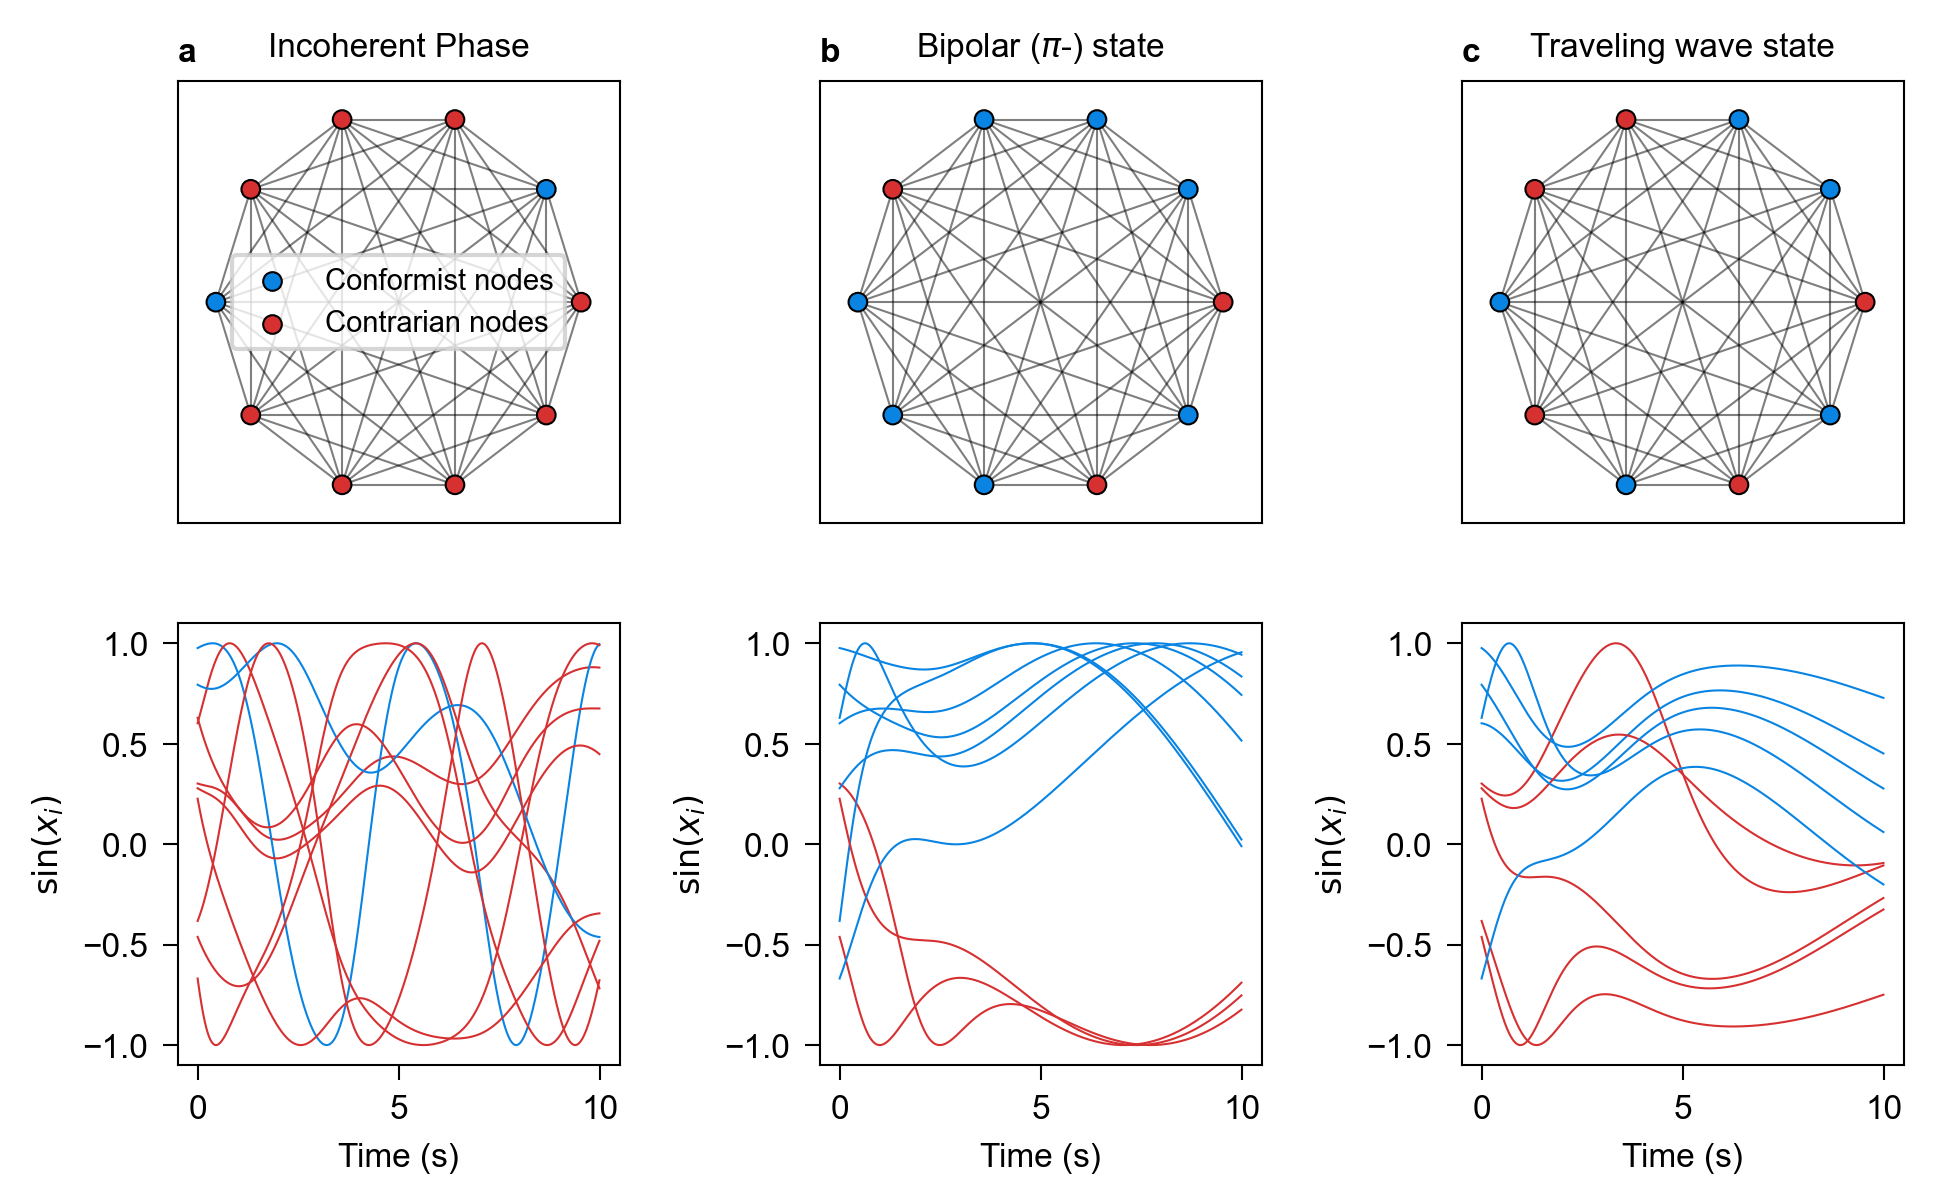

In [ ]:
fi, fig, axes = get_fig(2, 3, FW=18, LM=6, RM=6, TM=6, BM=6, HS=6, VS=3, fontsize=8)

ax = axes[0]
data = json.load(open('./data/hetero/incoherent.json', 'r'))
data['omega'] = data['omega'][0]
data['K'] = data['K'][0]
graph = nx.from_numpy_array(np.array(data['A']).astype(int))
pos = nx.circular_layout(graph)
node_color = ['#0984e3' if k > 0 else '#d63031' for k in data['K']]
nx.draw_networkx_edges(graph, pos, ax=ax, width=0.5, alpha=0.5)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=20, node_color=node_color, edgecolors='k', linewidths=0.5)
ax.set_title('Incoherent Phase')
ax.text(0, 1.03, 'a', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)
ax.legend(
    [
        plt.scatter([], [], color='#0984e3', label='Positive', edgecolors='k', linewidths=0.5, s=20),
        plt.scatter([], [], color='#d63031', label='Negative', edgecolors='k', linewidths=0.5, s=20),
    ],
    [ 'Conformist nodes', 'Contrarian nodes' ],
    loc='center', fontsize=7
)

# ax = axes[1]
# ax.bar(np.arange(len(data['omega'])), data['omega'], color='#636e72', width=0.75)
# ax.set_xlabel('Node Index')
# ax.set_ylabel(r'$\omega_i$')

# ax = axes[2]
# ax.bar(np.arange(len(data['K'])), data['K'], color='#636e72', width=0.75)
# ax.set_xlabel('Node Index')
# ax.set_ylabel(r'$\omega_i$')

ax = axes[3]
time = np.arange(1000) * 0.01
for i in range(10):
    ax.plot(time, np.sin(data['x'])[:, i], label=f'Node {i+1}', color=node_color[i])
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\sin(x_i)$')

ax = axes[1]
data = json.load(open('./data/hetero/bipolar.json', 'r'))
data['omega'] = data['omega'][0]
data['K'] = data['K'][0]
graph = nx.from_numpy_array(np.array(data['A']).astype(int))
pos = nx.circular_layout(graph)
node_color = ['#0984e3' if k > 0 else '#d63031' for k in data['K']]
nx.draw_networkx_edges(graph, pos, ax=ax, width=0.5, alpha=0.5)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=20, node_color=node_color, edgecolors='k', linewidths=0.5)
ax.set_title('Bipolar ($\\pi$-) state')
ax.text(0, 1.03, 'b', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

ax = axes[4]
time = np.arange(1000) * 0.01
for i in range(10):
    ax.plot(time, np.sin(data['x'])[:, i], label=f'Node {i+1}', color=node_color[i])
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\sin(x_i)$')

ax = axes[2]
data = json.load(open('./data/hetero/traveling.json', 'r'))
data['omega'] = data['omega'][0]
data['K'] = data['K'][0]
graph = nx.from_numpy_array(np.array(data['A']).astype(int))
pos = nx.circular_layout(graph)
node_color = ['#0984e3' if k > 0 else '#d63031' for k in data['K']]
nx.draw_networkx_edges(graph, pos, ax=ax, width=0.5, alpha=0.5)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=20, node_color=node_color, edgecolors='k', linewidths=0.5)
ax.set_title('Traveling wave state')
ax.text(0, 1.03, 'c', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

ax = axes[5]
time = np.arange(1000) * 0.01
for i in range(10):
    ax.plot(time, np.sin(data['x'])[:, i], label=f'Node {i+1}', color=node_color[i])
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\sin(x_i)$')

fig.savefig('./plot/hetero/demo.pdf', bbox_inches='tight', dpi=600)

Text(0, 0.5, '$\\sin(x_i)$')

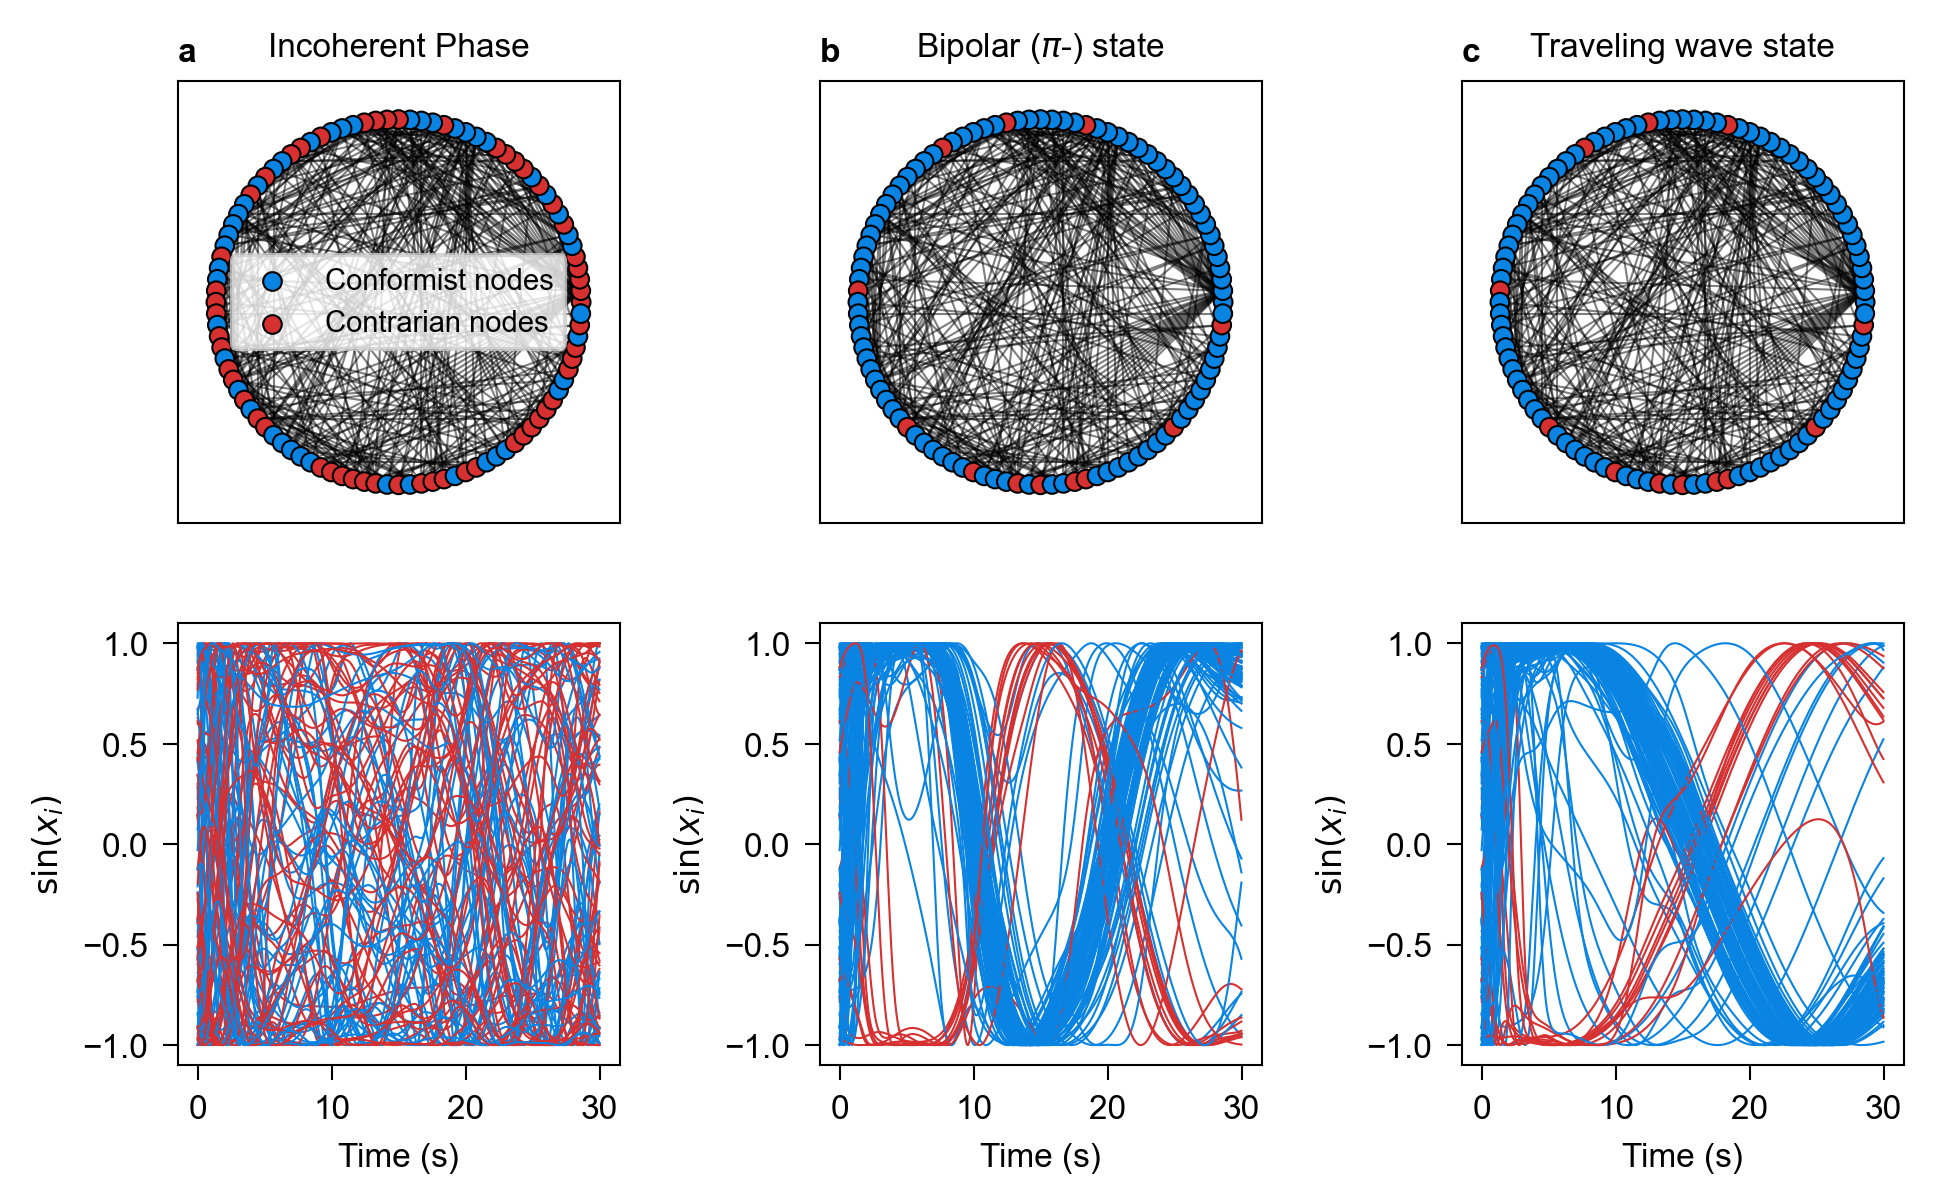

In [ ]:
fi, fig, axes = get_fig(2, 3, FW=18, LM=6, RM=6, TM=6, BM=6, HS=6, VS=3, fontsize=8)

ax = axes[0]
data = json.load(open('./data/test/incoherent.json', 'r'))
graph = nx.from_numpy_array(np.array(data['A']).astype(int))
pos = nx.circular_layout(graph)
node_color = ['#0984e3' if k > 0 else '#d63031' for k in data['K']]
nx.draw_networkx_edges(graph, pos, ax=ax, width=0.5, alpha=0.5)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=20, node_color=node_color, edgecolors='k', linewidths=0.5)
ax.set_title('Incoherent Phase')
ax.text(0, 1.03, 'a', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)
ax.legend(
    [
        plt.scatter([], [], color='#0984e3', label='Positive', edgecolors='k', linewidths=0.5, s=20),
        plt.scatter([], [], color='#d63031', label='Negative', edgecolors='k', linewidths=0.5, s=20),
    ],
    [ 'Conformist nodes', 'Contrarian nodes' ],
    loc='center', fontsize=7
)

# ax = axes[1]
# ax.bar(np.arange(len(data['omega'])), data['omega'], color='#636e72', width=0.75)
# ax.set_xlabel('Node Index')
# ax.set_ylabel(r'$\omega_i$')

# ax = axes[2]
# ax.bar(np.arange(len(data['K'])), data['K'], color='#636e72', width=0.75)
# ax.set_xlabel('Node Index')
# ax.set_ylabel(r'$\omega_i$')

ax = axes[3]
time = np.arange(3000) * 0.01
for i in range(100):
    ax.plot(time, np.sin(data['x'])[:, i], label=f'Node {i+1}', color=node_color[i])
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\sin(x_i)$')

ax = axes[1]
data = json.load(open('./data/test/bipolar.json', 'r'))
graph = nx.from_numpy_array(np.array(data['A']).astype(int))
pos = nx.circular_layout(graph)
node_color = ['#0984e3' if k > 0 else '#d63031' for k in data['K']]
nx.draw_networkx_edges(graph, pos, ax=ax, width=0.5, alpha=0.5)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=20, node_color=node_color, edgecolors='k', linewidths=0.5)
ax.set_title('Bipolar ($\\pi$-) state')
ax.text(0, 1.03, 'b', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

ax = axes[4]
time = np.arange(3000) * 0.01
for i in range(100):
    ax.plot(time, np.sin(data['x'])[:, i], label=f'Node {i+1}', color=node_color[i])
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\sin(x_i)$')

ax = axes[2]
data = json.load(open('./data/test/traveling.json', 'r'))
graph = nx.from_numpy_array(np.array(data['A']).astype(int))
pos = nx.circular_layout(graph)
node_color = ['#0984e3' if k > 0 else '#d63031' for k in data['K']]
nx.draw_networkx_edges(graph, pos, ax=ax, width=0.5, alpha=0.5)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=20, node_color=node_color, edgecolors='k', linewidths=0.5)
ax.set_title('Traveling wave state')
ax.text(0, 1.03, 'c', fontsize=8, ha='left', va='bottom', weight='bold', transform=ax.transAxes)

ax = axes[5]
time = np.arange(3000) * 0.01
for i in range(100):
    ax.plot(time, np.sin(data['x'])[:, i], label=f'Node {i+1}', color=node_color[i])
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$\sin(x_i)$')
